# Image Clustering

This example shows how SentenceTransformer can be used for Image Clustering.

As model, we use the [OpenAI CLIP Model](https://github.com/openai/CLIP), which was trained on a large set of images and image alt texts.  
Note that the CLIP is now from 2021 and more recent models exist. We use it for this illustration because it is small and therefore run on a Google Colab GPU.  
As an alternative, you can check the models with the [`zero-shot-image-classification`](https://huggingface.co/models?pipeline_tag=zero-shot-image-classification) pipeline tag on the 🤗 Hub.  
You can also test [trimmed](https://huggingface.co/blog/lbourdois/introduction-to-trimming) models that have the advantage of being smaller than the models from which they are derived while keeping the same performance. To find these models, we invite you to look at the `visual embedding` models listed in this [Space](https://huggingface.co/spaces/alphaedge-ai/Trimming_models_search).

As a source for photos, we use the [Unsplash Dataset Lite](https://unsplash.com/data), which contains about 25k images. See the [License](https://unsplash.com/license) about the Unsplash images.

We encode all images into vector space and then find high density regions in this vector space, i.e., regions where the images are fairly similar.

In [11]:
from datasets import load_dataset
from IPython.display import display

from sentence_transformers import SentenceTransformer
from sentence_transformers.util import community_detection

In [12]:
# First, we load the respective CLIP model
model = SentenceTransformer("sentence-transformers/clip-ViT-B-32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8869.10it/s]


In [13]:
# Next, we load the Unsplash Dataset Lite
unsplash = load_dataset("sentence-transformers/unsplash-lite")

# We can see that the dataset contains a column containing the images
# but also a column containing keywords that we will not use here.
unsplash

Generating train split: 100%|██████████| 24996/24996 [00:02<00:00, 9445.83 examples/s] 


DatasetDict({
    train: Dataset({
        features: ['image', 'keywords'],
        num_rows: 24996
    })
})

In [14]:
# Now, we need to compute the embeddings
# The attached function will be required for the following cell
# in the case where precomputed embeddings are not used .
embeddings_name = "embeddings_clip-ViT-B-32"


def embed(batch):
    """
    adds to the dataset a column of embeddings of images calculated with the model
    """
    image = batch["image"]
    return {embeddings_name: model.encode(image, convert_to_tensor=True)}

In [15]:
# Here for the calculation of the embeddings, you have 2 choices:
# 1) `use_precomputed_embeddings = True` and in that case you can
# use embeddings that we have already pre-calculated in order to speed up
# the execution of the notebook.
# 2) `use_precomputed_embeddings = False` and compute the embeddings on the fly.
# Takes about 9 minutes on a Google Colab T4

use_precomputed_embeddings = True

if use_precomputed_embeddings:
    embeddings_ds = load_dataset("sentence-transformers/unsplash-lite", name=embeddings_name, split="train")
    unsplash["train"] = unsplash["train"].add_column(embeddings_name, embeddings_ds[embeddings_name])

else:
    unsplash = unsplash.map(embed, batched=True, batch_size=16)

    # Uncomment the rest of the else condition if you want to save the embeddings
    # on the Hub to use `use_precomputed_embeddings = True` in the future

    # # We delete 'image' and 'keywords' so as not to save them as duplicates unnecessarily
    # embeddings_ds = unsplash['train'].remove_columns(['image', 'keywords'])
    # embeddings_ds.push_to_hub(
    #     "your_username/unsplash-lite", # your username
    #     config_name=embeddings_name,
    #     split="train",
    #     token="hf_xx" # your HF token
    # )

# We now have a new column containing our embeddings
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords', 'embeddings_clip-ViT-B-32'],
        num_rows: 24996
    })
})

In [16]:
# Now we run the clustering algorithm
# With the threshold parameter, we define at which threshold we identify two images as similar.
# Set the threshold lower, and you will get larger clusters which have less similar images in it
# (e.g. black cat images vs. cat images vs. animal images).
# With min_community_size, we define that we only want to have clusters of a certain minimal size

# Note: about 2 minutes on a Google Colab T4

img_emb = unsplash["train"][embeddings_name]
clusters = community_detection(img_emb, threshold=0.9, min_community_size=10)
print("Total number of clusters:", len(clusters))

Total number of clusters: 418




Cluster size: 512


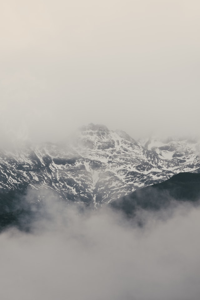

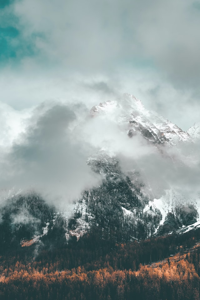

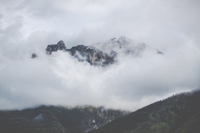



Cluster size: 413


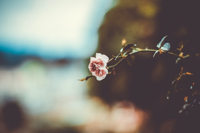

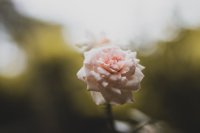

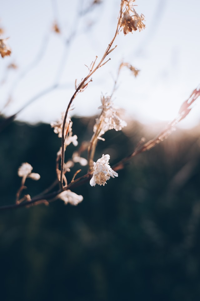



Cluster size: 378


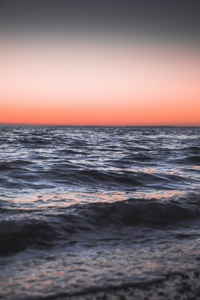

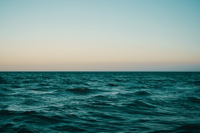

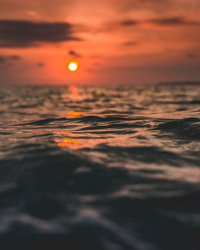



Cluster size: 291


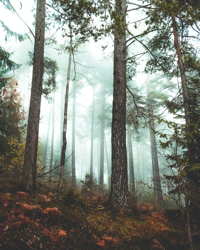

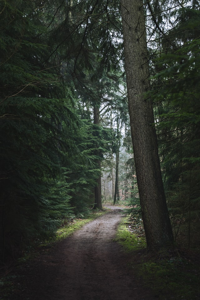

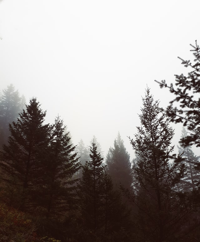



Cluster size: 286


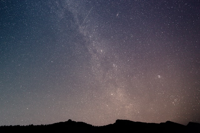

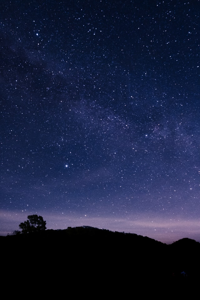

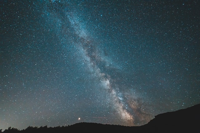



Cluster size: 158


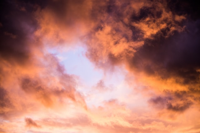

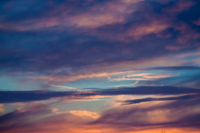

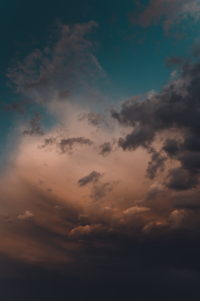



Cluster size: 147


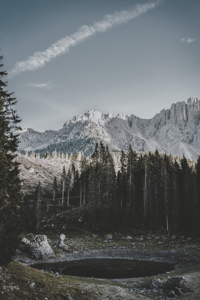

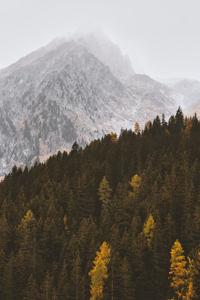

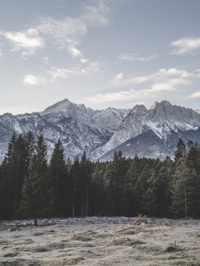



Cluster size: 132


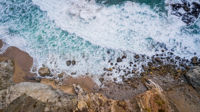

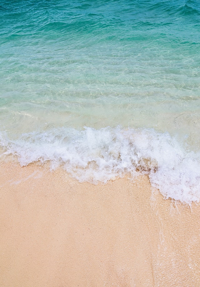

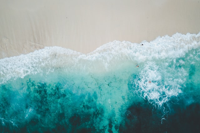



Cluster size: 121


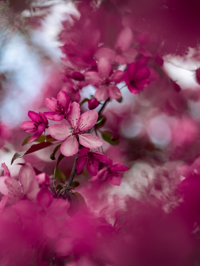

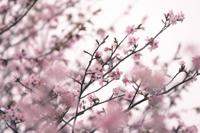

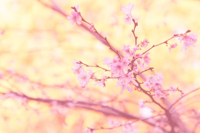



Cluster size: 118


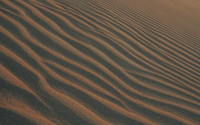

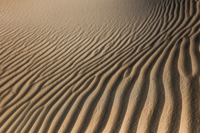

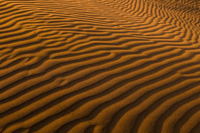

In [17]:
# Now we output the first 10 (largest) clusters
for cluster in clusters[0:10]:
    print("\n\nCluster size:", len(cluster))

    # Output 3 images
    for idx in cluster[0:3]:
        # original size
        # display(unsplash["train"][idx]["image"])

        # width=200px
        display(
            unsplash["train"][idx]["image"].resize(
                (200, int(200 * unsplash["train"][idx]["image"].height / unsplash["train"][idx]["image"].width))
            )
        )